In [1]:
# import zipfile
# from tqdm import tqdm

# fname = './UDE Diatoms in the Wild 2024 Sample.zip'
# path = './home/jupyter/project/UDE Diatoms in the Wild 2024 Sample.zip'

# with zipfile.ZipFile(fname, 'r') as zf:
#     for entry in tqdm(zf.infolist(), desc='Extracting '):
#         try:
#             zf.extract(entry, path)
#         except zipfile.error as e:
#             pass


Extracting : 100%|██████████| 29457/29457 [05:24<00:00, 90.69it/s] 


In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

import xml.etree.ElementTree as ET
import cv2
import albumentations as A
from albumentations import BboxParams
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision import datasets

from sklearn.model_selection import train_test_split

import math
import random
from tqdm import tqdm

from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
NUM_CLASSES = 31
BATCH_SIZE = 32  
LEARNING_RATE = 0.001
MOMENTUM = 0.9
EPOCHS_TEST = 2  
EPOCHS_TRAIN = 50  
RANDOM_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

csv_path = '/home/jupyter/project/home/jupyter/project/UDE Diatoms in the Wild 2024 Sample.zip/UDE Diatoms in the Wild 2024/UDE Diatoms in the Wild 2024/UDE Diatoms in the Wild 2024 Sample.csv'
img_dir = '/home/jupyter/project/home/jupyter/project/UDE Diatoms in the Wild 2024 Sample.zip/UDE Diatoms in the Wild 2024/UDE Diatoms in the Wild 2024/images'
# !Заменить в сфере

In [3]:
# ==================== АУГМЕНТАЦИИ И ТРАНСФОРМАЦИИ ====================


INPUT_SIZE = (128, 432)


base_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augment_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ==================== ДАТАСЕТ С БАЛАНСИРОВКОЙ ====================
class BalancedImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, target_samples=None, augment_threshold=1000):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        
        self.species_list = sorted(self.data['species'].unique().tolist())
        self.species2label = {species: idx for idx, species in enumerate(self.species_list)}
        self.label2species = {idx: species for species, idx in self.species2label.items()}
        

        self.class_counts = self.data['species'].value_counts().to_dict()
        # for species, count in sorted(self.class_counts.items(), key=lambda x: x[1], reverse=True):
        #     print(f"{species}: {count}")
        
        self.augment_classes = [
            species for species, count in self.class_counts.items() 
            if count < augment_threshold
        ]
        
        self.samples = []
        for species in self.species_list:
            species_data = self.data[self.data['species'] == species]
            count = len(species_data)
            

            if target_samples and count < target_samples:
                repeat_times = target_samples // count
                remainder = target_samples % count
                
                for _ in range(repeat_times):
                    for _, row in species_data.iterrows():
                        self.samples.append((row['cutout_filename'], species, True))
                
                for idx in range(remainder):
                    row = species_data.iloc[idx]
                    self.samples.append((row['cutout_filename'], species, True))
            else:
                for _, row in species_data.iterrows():
                    use_augment = species in self.augment_classes
                    self.samples.append((row['cutout_filename'], species, use_augment))
        
        print(f"Всего после аугментаций: {len(self.samples)}")
    

    def __len__(self):
        return len(self.samples)
    

    def __getitem__(self, idx):
        img_name, species, use_augment = self.samples[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        label = self.species2label[species]
        
        if use_augment:
            transform = augment_transform
        else:
            transform = base_transform
        
        image = transform(image)
        return image, label




# ==================== СОЗДАНИЕ ДАТАСЕТОВ ====================

class_counts = pd.read_csv(csv_path)['species'].value_counts()
# target_per_class = int(class_counts.median())
target_per_class = 1000

print(f"Целевое количество образцов на класс: {target_per_class}")


full_dataset = BalancedImageDataset(
    csv_path, 
    img_dir,
    target_samples=target_per_class,
    augment_threshold=1000
)


all_labels = [full_dataset.species2label[species] for _, species, _ in full_dataset.samples]

indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.3,
    stratify=all_labels,
    random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=[all_labels[i] for i in temp_idx],
    random_state=RANDOM_SEED
)


train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
test_dataset = torch.utils.data.Subset(full_dataset, test_idx)


print(f"Размеры датасетов:")
print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Целевое количество образцов на класс: 1000
Всего после аугментаций: 41132
Размеры датасетов:
Train: 28792
Val: 6170
Test: 6170


In [4]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, reduce_3x3, out_3x3, reduce_5x5, out_5x5, pool_proj):
        super(InceptionModule, self).__init__()
        
        # 1x1 ветка
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU(inplace=True)
        )
        
        # 3x3 ветка
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_3x3, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(reduce_3x3),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_3x3, out_3x3, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU(inplace=True)
        )
        
        # 5x5 ветка
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_5x5, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(reduce_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_5x5, out_5x5, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True)
        )
        
        # MaxPooling ветка
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)

        return torch.cat([branch1, branch2, branch3, branch4], dim=1)


class DiatomNet(nn.Module):
    def __init__(self, num_classes=68):
        super(DiatomNet, self).__init__()
        
        # Слой 1: Convolutional 7x7
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # MaxPool 3x3
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Слой 2: Convolutional 3x3
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True)
        )
        
        # MaxPool 3x3
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Inception модуль 1
        self.inception1 = InceptionModule(
            in_channels=192,
            out_1x1=64,
            reduce_3x3=96,
            out_3x3=128,
            reduce_5x5=16,
            out_5x5=32,
            pool_proj=32
        )
        
        # MaxPool 3x3
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Inception модуль 2
        self.inception2 = InceptionModule(
            in_channels=256,
            out_1x1=192,
            reduce_3x3=96,
            out_3x3=208,
            reduce_5x5=16,
            out_5x5=48,
            pool_proj=64
        )
        
        # MaxPool 3x3
        self.pool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Inception модуль 3
        self.inception3 = InceptionModule(
            in_channels=512,
            out_1x1=384,
            reduce_3x3=192,
            out_3x3=384,
            reduce_5x5=48,
            out_5x5=128,
            pool_proj=128
        )
        
        # Adaptive Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dropout 40%
        self.dropout = nn.Dropout(0.4)
        
        # Полносвязный слой
        self.fc = nn.Linear(1024, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.pool2(x)
        
        x = self.inception1(x)
        x = self.pool3(x)
        
        x = self.inception2(x)
        x = self.pool4(x)
        
        x = self.inception3(x)
        x = self.avgpool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x

In [5]:
# ==================== ФУНКЦИИ ОБУЧЕНИЯ ====================


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, epochs, lr=LEARNING_RATE, momentum=MOMENTUM):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 50)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"Current leraning rate: {current_lr:.4f}")
        

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_diatomnet.pth')
            print(f"Model saved with val_acc: {best_val_acc:.4f}")
    
    return train_losses, train_accs, val_losses, val_accs

In [6]:
# ==================== ТЕСТОВЫЙ ЗАПУСК (1 эпоха на маленьком датасете) ====================

print("\n" + "="*60)
print("ТЕСТОВЫЙ ЗАПУСК (1 эпоха на датасете)")
print("="*60)


test_batch_size = 8
small_dataset = torch.utils.data.Subset(full_dataset, range(32))  # Берем первые 32 изображения


test_train_loader = DataLoader(small_dataset, batch_size=test_batch_size, shuffle=True)
test_val_loader = DataLoader(small_dataset, batch_size=test_batch_size, shuffle=False)


model_test = DiatomNet(num_classes=NUM_CLASSES).to(device)
print(f"Количество параметров: {sum(p.numel() for p in model_test.parameters()):,}")


test_images, test_labels = next(iter(test_train_loader))
test_images = test_images.to(device)
test_output = model_test(test_images)
print(f"Размер входа: {test_images.shape}")
print(f"Размер выхода: {test_output.shape}")
print(f"Форма выхода должна быть: [batch_size, {NUM_CLASSES}]")
print("Forward pass успешен!")


print("\nЗапуск тестового обучения на 1 эпоху...")
train_losses_test, train_accs_test, val_losses_test, val_accs_test = train_model(
    model_test, test_train_loader, test_val_loader, epochs=1
)

print(f'train_losses_test, train_accs_test, val_losses_test, val_accs_test:') 
print(f'{train_losses_test, train_accs_test, val_losses_test, val_accs_test}')



ТЕСТОВЫЙ ЗАПУСК (1 эпоха на датасете)
Количество параметров: 1,817,935
Размер входа: torch.Size([8, 3, 128, 432])
Размер выхода: torch.Size([8, 31])
Форма выхода должна быть: [batch_size, 31]
Forward pass успешен!

Запуск тестового обучения на 1 эпоху...

Epoch 1/1
--------------------------------------------------


Train Loss: 2.5512, Train Acc: 0.5625
Val Loss: 2.6211, Val Acc: 1.0000
Current leraning rate: 0.0010
Model saved with val_acc: 1.0000
train_losses_test, train_accs_test, val_losses_test, val_accs_test:
([2.5511779189109802], [0.5625], [2.621124744415283], [1.0])


In [7]:
# ==================== РЕАЛЬНЫЙ ЦИКЛ ОБУЧЕНИЯ ====================

print("\n" + "="*60)
print("РЕАЛЬНЫЙ ЦИКЛ ОБУЧЕНИЯ")
print("="*60)

model = DiatomNet(num_classes=NUM_CLASSES).to(device)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")


train_losses, train_accs, val_losses, val_accs = train_model(
    model, train_loader, val_loader, epochs=EPOCHS_TRAIN
)

model.load_state_dict(torch.load('best_diatomnet.pth'))

# ==================== ТЕСТИРОВАНИЕ ====================
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА ТЕСТОВОМ ДАТАСЕТЕ")
print("="*60)

test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


РЕАЛЬНЫЙ ЦИКЛ ОБУЧЕНИЯ
Количество параметров: 1,817,935

Epoch 1/50
--------------------------------------------------


Train Loss: 1.9094, Train Acc: 0.3608
Val Loss: 2.0501, Val Acc: 0.3744
Current leraning rate: 0.0010


Model saved with val_acc: 0.3744

Epoch 2/50
--------------------------------------------------


Train Loss: 1.3968, Train Acc: 0.5225
Val Loss: 1.3420, Val Acc: 0.5420
Current leraning rate: 0.0010


Model saved with val_acc: 0.5420

Epoch 3/50
--------------------------------------------------


...

Train Loss: 0.1805, Train Acc: 0.9404
Val Loss: 0.4498, Val Acc: 0.8671
Current leraning rate: 0.0000

Epoch 49/50
--------------------------------------------------


Train Loss: 0.1822, Train Acc: 0.9407
Val Loss: 0.4350, Val Acc: 0.8687
Current leraning rate: 0.0000

Epoch 50/50
--------------------------------------------------


Train Loss: 0.1794, Train Acc: 0.9418
Val Loss: 0.4401, Val Acc: 0.8692
Current leraning rate: 0.0000



ТЕСТИРОВАНИЕ НА ТЕСТОВОМ ДАТАСЕТЕ



Test Accuracy: 0.8632
Test Loss: 0.4472


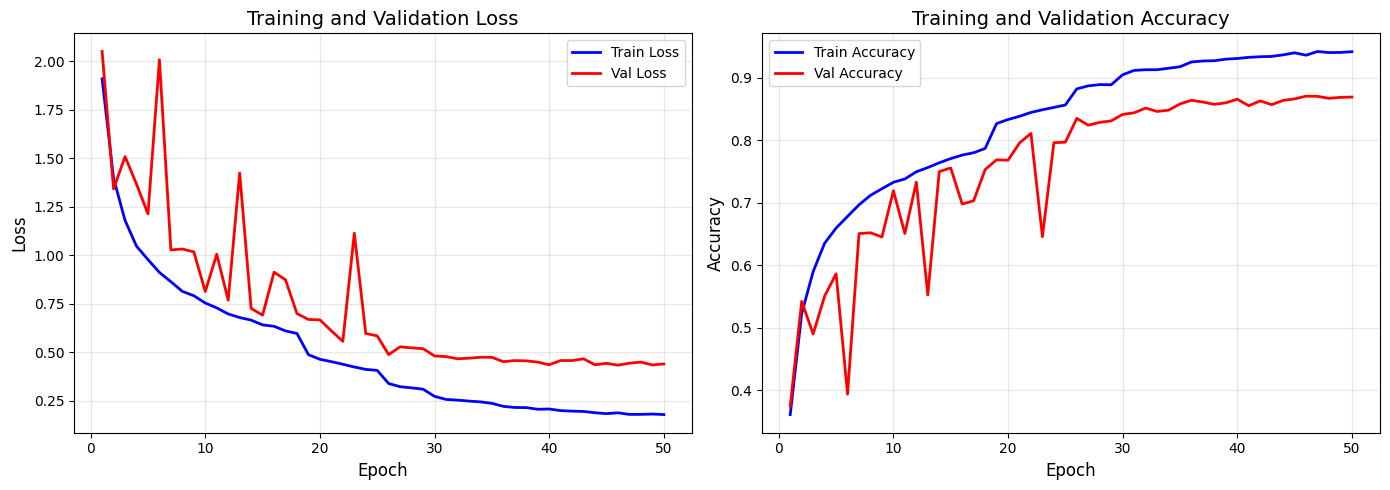

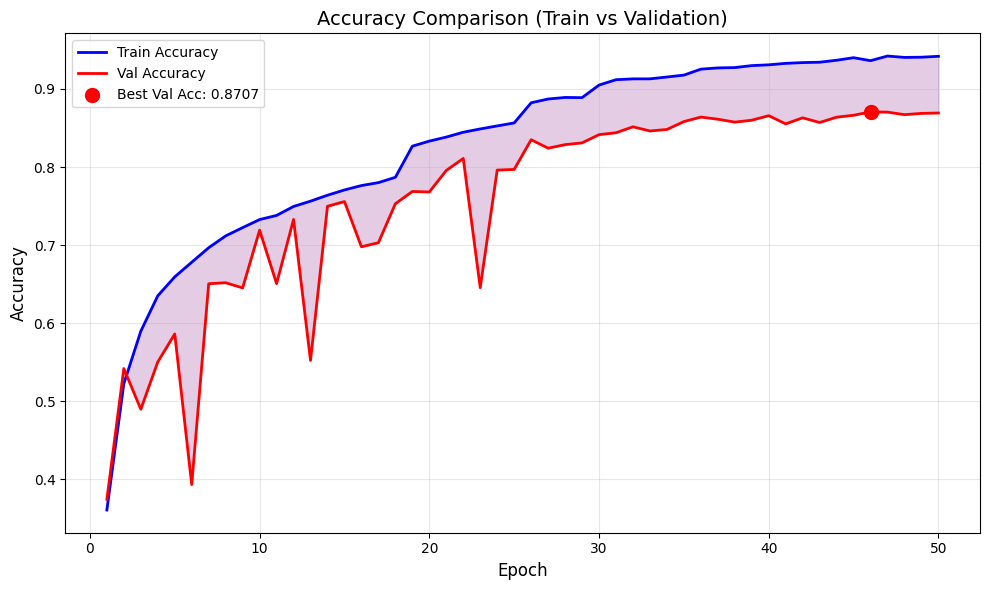


ОБУЧЕНИЕ ЗАВЕРШЕНО!
Лучшая валидационная точность: 0.8707
Тестовая точность: 0.8632
Модель сохранена как 'best_diatomnet.pth'
Графики сохранены как 'training_metrics.png' и 'accuracy_comparison.png'


In [8]:
# ==================== ПОСТРОЕНИЕ ГРАФИКОВ ====================
def plot_metrics(train_losses, train_accs, val_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График точности
    ax2.plot(epochs, train_accs, 'b-', label='Train Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Val Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Дополнительный график - сравнение точности
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_accs, 'b-', label='Train Accuracy', linewidth=2)
    ax.plot(epochs, val_accs, 'r-', label='Val Accuracy', linewidth=2)
    ax.fill_between(epochs, train_accs, val_accs, alpha=0.2, color='purple')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Accuracy Comparison (Train vs Validation)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Отмечаем лучшую точность
    best_val_idx = np.argmax(val_accs)
    ax.scatter(best_val_idx + 1, val_accs[best_val_idx], 
               color='red', s=100, zorder=5, 
               label=f'Best Val Acc: {val_accs[best_val_idx]:.4f}')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# Построение графиков
plot_metrics(train_losses, train_accs, val_losses, val_accs)

print("\n" + "="*60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("="*60)
print(f"Лучшая валидационная точность: {max(val_accs):.4f}")
print(f"Тестовая точность: {test_acc:.4f}")
print(f"Модель сохранена как 'best_diatomnet.pth'")
print(f"Графики сохранены как 'training_metrics.png' и 'accuracy_comparison.png'")